In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import simpson

In [2]:
plt.rcParams.update({
    "figure.figsize": (10, 10),
    "axes.titlesize": 32,
    "axes.labelsize": 26,
    "xtick.labelsize": 23,
    "ytick.labelsize": 22,
    "legend.fontsize": 22,
    "figure.titlesize": 32,
    "lines.linewidth": 2,
    "axes.grid": False,
})

## Double first order

In [3]:
def time_2first_ord(t, x, glut_type=0, t2=10000, taux=100, tauu=100, tauK=3, taug=5, A1=1, A2=1, alpha=1, U_0=0.5):
    
    X = x[0]
    U = x[1]
    K = x[2]
    g = x[3]
    
    
#   exponential pulses
    if glut_type == 0:
        if  t<t2:
            glutamate = 1*(np.exp(-(t)/tauS))
        else:
            glutamate = 1*((np.exp(-(t)/tauS) + np.exp(-(t-t2)/tauS)))
        # 1/100 to make it in terms of 10mM instead of M
        
#   Square pulses
    if glut_type == 1:
        if t>0 and t<=1:   
            glutamate = 1
        else:
            glutamate = 0

#   Step increase 
    if glut_type == 2:
        if t>10 :   
            glutamate = 1
        else:
            glutamate = 0

#   Periodic square pulses
    if glut_type == 3:
        if t%(1000/t2)<=1:
            glutamate = 1
        else:
            glutamate = 0
            
#   Sinusodial signal
    if glut_type == 4:
        glutamate = 0.005*(1+np.sin(2*np.pi*(t2/1000)*t))
        
#   Paired Square Pulse
    if glut_type == 5:
        if t>=0 and t<100 or t>=t2 and t<100+t2:   
            glutamate = 1
        else:
            glutamate = 0

            
#   Square pulse of certain length
    if glut_type == 6:
        if t>=0 and t<t2:  
            glutamate = 1
        else:
            glutamate = 0
        

    
    U_plus = U #+ (U_0 * (1.0 - U))*glutamate
    dU = (U_0 - U)/tauu + (U_0 * (1.0 - U))*glutamate
    
    dX = (1-X)/taux - (alpha * U_plus * X)*glutamate#(alpha * U_plus * X)*glutamate

        
    dK = -K/tauK + (A1 * U_plus * X)*glutamate #(A1 * U_plus * X)*glutamate
    dg = -g/taug + (A2 * U_plus * X)*glutamate #(A2 * U_plus * X)*glutamate


    return np.array([dX, dU, dK, dg])

In [4]:
# Not using this anymore

def time_2first_ord_noU(t, x, glut_type=0, t2=10000, taux=100, tauu=100, tauK=3, taug=5, A1=1, A2=1, alpha=1, U_0=0.5):
    
    X = x[0]
    K = x[1]
    g = x[2]
    
    
#   exponential pulses
    if glut_type == 0:
        if  t<t2:
            glutamate = 1*(np.exp(-(t)/tauS))
        else:
            glutamate = 1*((np.exp(-(t)/tauS) + np.exp(-(t-t2)/tauS)))
        # 1/100 to make it in terms of 10mM instead of M
        
#   Square pulses
    if glut_type == 1:
        if t>0 and t<=1:   
            glutamate = 1
        else:
            glutamate = 0

#   Step increase 
    if glut_type == 2:
        if t>10 :   
            glutamate = 1
        else:
            glutamate = 0

#   Periodic square pulses
    if glut_type == 3:
        if t%(1000/t2)<=1:
            glutamate = 1
        else:
            glutamate = 0
            
#   Sinusodial signal
    if glut_type == 4:
        glutamate = 0.005*(1+np.sin(2*np.pi*(t2/1000)*t))
        
#   Paired Square Pulse
    if glut_type == 5:
        if t>=0 and t<100 or t>=t2 and t<100+t2:   
            glutamate = 1
        else:
            glutamate = 0

            
#   Square pulse of certain length
    if glut_type == 6:
        if t>=0 and t<t2:  
            glutamate = 1
        else:
            glutamate = 0

    
    dX = (1-X)/taux - (alpha * X)*glutamate#(alpha * U_plus * X)*glutamate

        
    dK = -K/tauK + (A1 * X)*glutamate #(A1 * U_plus * X)*glutamate
    dg = -g/taug + (A2 * X)*glutamate #(A2 * U_plus * X)*glutamate


    return np.array([dX, dK, dg])

## Milstein

In [5]:
#Normal
alpha = 6   # Deactivation rate
beta = 10    # Activation rate
k_plus1 = 1e4 # Binding rate of molecule to AMPAR (R to RG)
k_minus1 = 50  # Unbinding rate of molecule from AMPAR (RG to R)
CC = 36.5      # Transition from RG to RG* (channel activating)
CO = 4.55     # Transition from RG* to RG (Channel deactivating)
CS_plus1 = 0.3   # Transition from RG* to RG*2
CS_minus1 = 10.0 # Transition from desensitized state RG*2 to RG*
gamma1  = .003 # Recovery rate
gamma2 = .03
delta1 = 1.1    # Desensitization rate from D1 to RG*
delta2 = .3    # Desensitization rate from D2 to RG*2
tauS = 3

#G2

#     CC = 25.0      # Transition from RG to RG* (channel activating)
#     CO = 2.5     # Transition from RG* to RG (Channel deactivating)
#     CS_plus1 = 1.0   # Transition from RG* to RG*2
#     CS_minus1 = 3.4 # Transition from desensitized state RG*2 to RG*
#     gamma1  = .03 # Recovery rate
#     gamma2 = .03

#     #G4
#     CC = 12.5      # Transition from RG to RG* (channel activating)
#     CO = 1.75     # Transition from RG* to RG (Channel deactivating)
#     CS_plus1 = 10.0   # Transition from RG* to RG*2
#     CS_minus1 = 4.2 # Transition from desensitized state RG*2 to RG*
#     gamma1  = .003 # Recovery rate
#     gamma2 = .03

In [6]:
def Milstein2007(t, y, glut_type=0, CC=36.5, CO=4.55, CS_plus1=0.3, CS_minus1=10.0, gamma1 =.003, gamma2 = 0.03, beta=10, t2=10000, delta1=1.1, delta2=0.3, briansconst=1.0):
    # t2 is the time of the second pulse for multi-pulse experiments 
    # and the frequency for periodic stimulus experiments
    
    R = y[0]
    RG = y[1]
    O1 = y[2]
    C1 = y[3]
    D1 = y[4]
    O2 = y[5]
    C2 = y[6]
    D2 = y[7]
    s = y[8]

#   exponential pulses
    if glut_type == 0:
        if  t<t2:
            glutamate = 0.01*(np.exp(-(t)/tauS))
        else:
            glutamate = 0.01*((np.exp(-(t)/tauS) + np.exp(-(t-t2)/tauS)))
        # 1/100 to make it in terms of 10mM instead of M
        
#   Square pulses
    if glut_type == 1:
        if t>0 and t<=1:   
            glutamate = 0.01
        else:
            glutamate = 0

#   Step increase 
    if glut_type == 2:
        if t>10 :   
            glutamate = 0.01
        else:
            glutamate = 0

#   Periodic square pulses
    if glut_type == 3:
        if t%(1000/t2)<=1:
            glutamate = 0.01
        else:
            glutamate = 0
            
#   Sinusodial signal
    if glut_type == 4:
        glutamate = 0.005*(1+np.sin(2*np.pi*(t2/1000)*t))
        
#   Paired Square Pulse
    if glut_type == 5:
        if t>=0 and t<100 or t>=t2 and t<100+t2:   
            glutamate = 0.01
        else:
            glutamate = 0

            
#   Square pulse of certain length
    if glut_type == 6:
        if t>=0 and t<t2:  
            glutamate = 0.01
        else:
            glutamate = 0
        
    
    dR_dt = k_minus1*RG - briansconst*glutamate*k_plus1*R #expon is equivalent to brianconst*s
    dRG_dt = briansconst*glutamate*k_plus1*R - k_minus1*RG + CO*C1 - CC*RG

    dC1_dt = CC*RG - CO*C1 + alpha*O1 - beta*C1 + gamma1*D1 - delta1*C1 + CS_minus1*C2 - CS_plus1*C1
    dO1_dt = beta*C1 - alpha*O1
    dD1_dt = delta1*C1 - gamma1*D1
    
    dC2_dt = CS_plus1*C1 - CS_minus1*C2 + alpha*O2 - beta*C2 + gamma2*D2 - delta2*C2
    dO2_dt = beta*C2 - alpha*O2
    dD2_dt = delta2*C2 - gamma2*D2
    
    ds_dt = -s/tauS
    
#     dC3_dt = CS_plus2*C2 - CS_minus2*C3 + alpha*O3 - beta*C3 + gamma2*D3 - delta3*C3
#     dO3_dt = beta*C3 - alpha*O3
#     dD3_dt = delta3*C3 - gamma2*D3

    
    return [dR_dt, dRG_dt, dO1_dt, dC1_dt, dD1_dt, dO2_dt, dC2_dt, dD2_dt, ds_dt]

In [7]:
# For Milstein 2007

R_0 = np.array([1.0])
RG_0 = np.array([0.0])
O1_0 = np.array([0.0])
C1_0 = np.array([0.0])
D1_0 = np.array([0.0])
O2_0 = np.array([0.0])
C2_0 = np.array([0.0])
D2_0 = np.array([0.0])
s_0 = np.array([0.0])

y3 = np.concatenate([R_0, RG_0, O1_0, C1_0, D1_0, O2_0, C2_0, D2_0, s_0])

In [8]:
alpha = 6   # Deactivation rate
beta = 10    # Activation rate
k_plus1 = 1e4 # Binding rate of molecule to AMPAR (R to RG)
k_minus1 = 50  # Unbinding rate of molecule from AMPAR (RG to R)
CC = 36.5      # Transition from RG to RG* (channel activating)
CO = 4.55     # Transition from RG* to RG (Channel deactivating)
CS_plus1 = 0.3   # Transition from RG* to RG*2
CS_minus1 = 10.0 # Transition from desensitized state RG*2 to RG*
gamma1  = .003 # Recovery rate
gamma2 = .03
delta1 = 1.1    # Desensitization rate from D1 to RG*
delta2 = .3    # Desensitization rate from D2 to RG*2
tauS = 3

solMil = solve_ivp(Milstein2007, [0, 20], y3, args =  (1, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, 10000, 1.1, 0.3, 1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
solMil2 = solve_ivp(Milstein2007, [0, 300], y3, args = (1, 25, 2.5, 1.0, 3.4, .03, 0.03, 100.0, 10000, 1.1, 0.3, 1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)

## Varying tauu

In [34]:
#TARPless
tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
taux, tauu, U_0 = [426.05575527,   0.66710861,   0.62727836]
y0 = np.array([1,U_0,0,0])


            #    taux=100, tauu=100, tauK=3, taug=5, A1=1, A2=1, alpha=1, U_0=0.5
sol_norm_s = solve_ivp(time_2first_ord, [0, 500], y0, args =  (3, 50, taux, 100, tauK, taug, A1, A2, alpha, U_0), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
sol_norm_f = solve_ivp(time_2first_ord, [0, 500], y0, args =  (3, 50, taux, 0.1, tauK, taug, A1, A2, alpha, U_0), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)

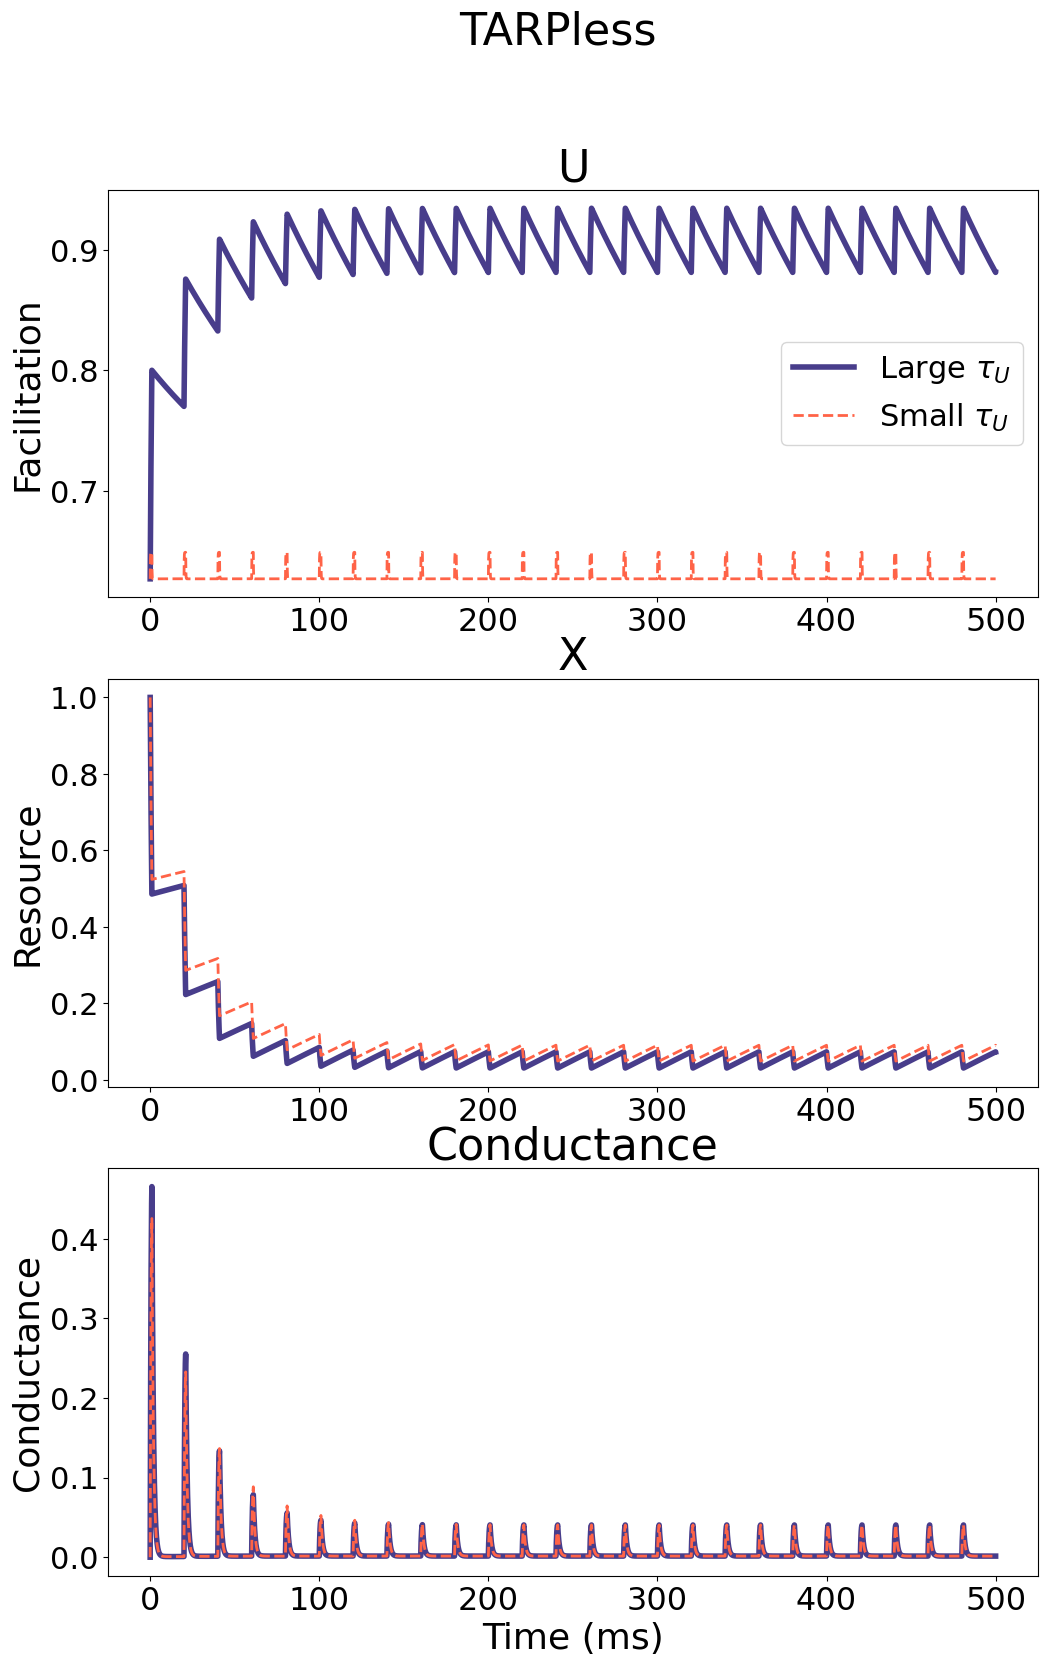

In [ ]:
plt.figure(figsize=(12,18))

plt.suptitle('TARPless')
plt.subplot(3,1,1)
plt.plot(sol_norm_s.t, sol_norm_s.y[1], linewidth=4, label = r'Large $\tau_U$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[1], label=r'Small $\tau_U$', linestyle='--', color='tomato')
plt.title('U')
plt.ylabel('Facilitation')
# plt.ylim(-0.001, 0.1)
# plt.xlim(-1, 100)
plt.legend()

plt.subplot(3,1,2)
plt.plot(sol_norm_s.t, sol_norm_s.y[0], linewidth=4, label = r'Large $\tau_U$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[0], label=r'Small $\tau_U$', linestyle='--', color='tomato')
plt.ylabel('Resource')
# plt.ylim(-0.001, 0.1)
# plt.xlim(-1, 100)
plt.title('X')

plt.subplot(3,1,3)
plt.plot(sol_norm_s.t, sol_norm_s.y[2] + sol_norm_s.y[3], linewidth=4, label = r'Large $\tau_U$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[2] + sol_norm_f.y[3], label=r'Small $\tau_U$', linestyle='--', color='tomato')
plt.title('Conductance')
plt.xlabel('Time (ms)')
plt.ylabel('Conductance')
# plt.ylim(-0.001, 0.05)
# plt.xlim(-1, 100)

# plt.savefig('Varying_tauU_TARPless_50Hz.pdf')

In [66]:
# Area under the curve of each
a = np.trapz(sol_norm_s.y[2] + sol_norm_s.y[3], sol_norm_s.t)
b = np.trapz(sol_norm_f.y[2] + sol_norm_f.y[3], sol_norm_f.t)

print('slow tauU = ', a)
print('fast tauU = ', b)

print('relative error = ', np.abs(a - b) / a, np.abs(b-a) / b)

slow tauU =  5.820574672209785
fast tauU =  5.696388474660328
relative error =  0.021335727920884177 0.021800865250304533


In [38]:
#TARPed
tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
y0 = np.array([1,U_0,0,0])

            #    taux=100, tauu=100, tauK=3, taug=5, A1=1, A2=1, alpha=1, U_0=0.5
sol_norm_s = solve_ivp(time_2first_ord, [0, 500], y0, args =  (3, 50, taux, 100, tauK, taug, A1, A2, alpha, U_0), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
sol_norm_f = solve_ivp(time_2first_ord, [0, 500], y0, args =  (3, 50, taux, 0.1, tauK, taug, A1, A2, alpha, U_0), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


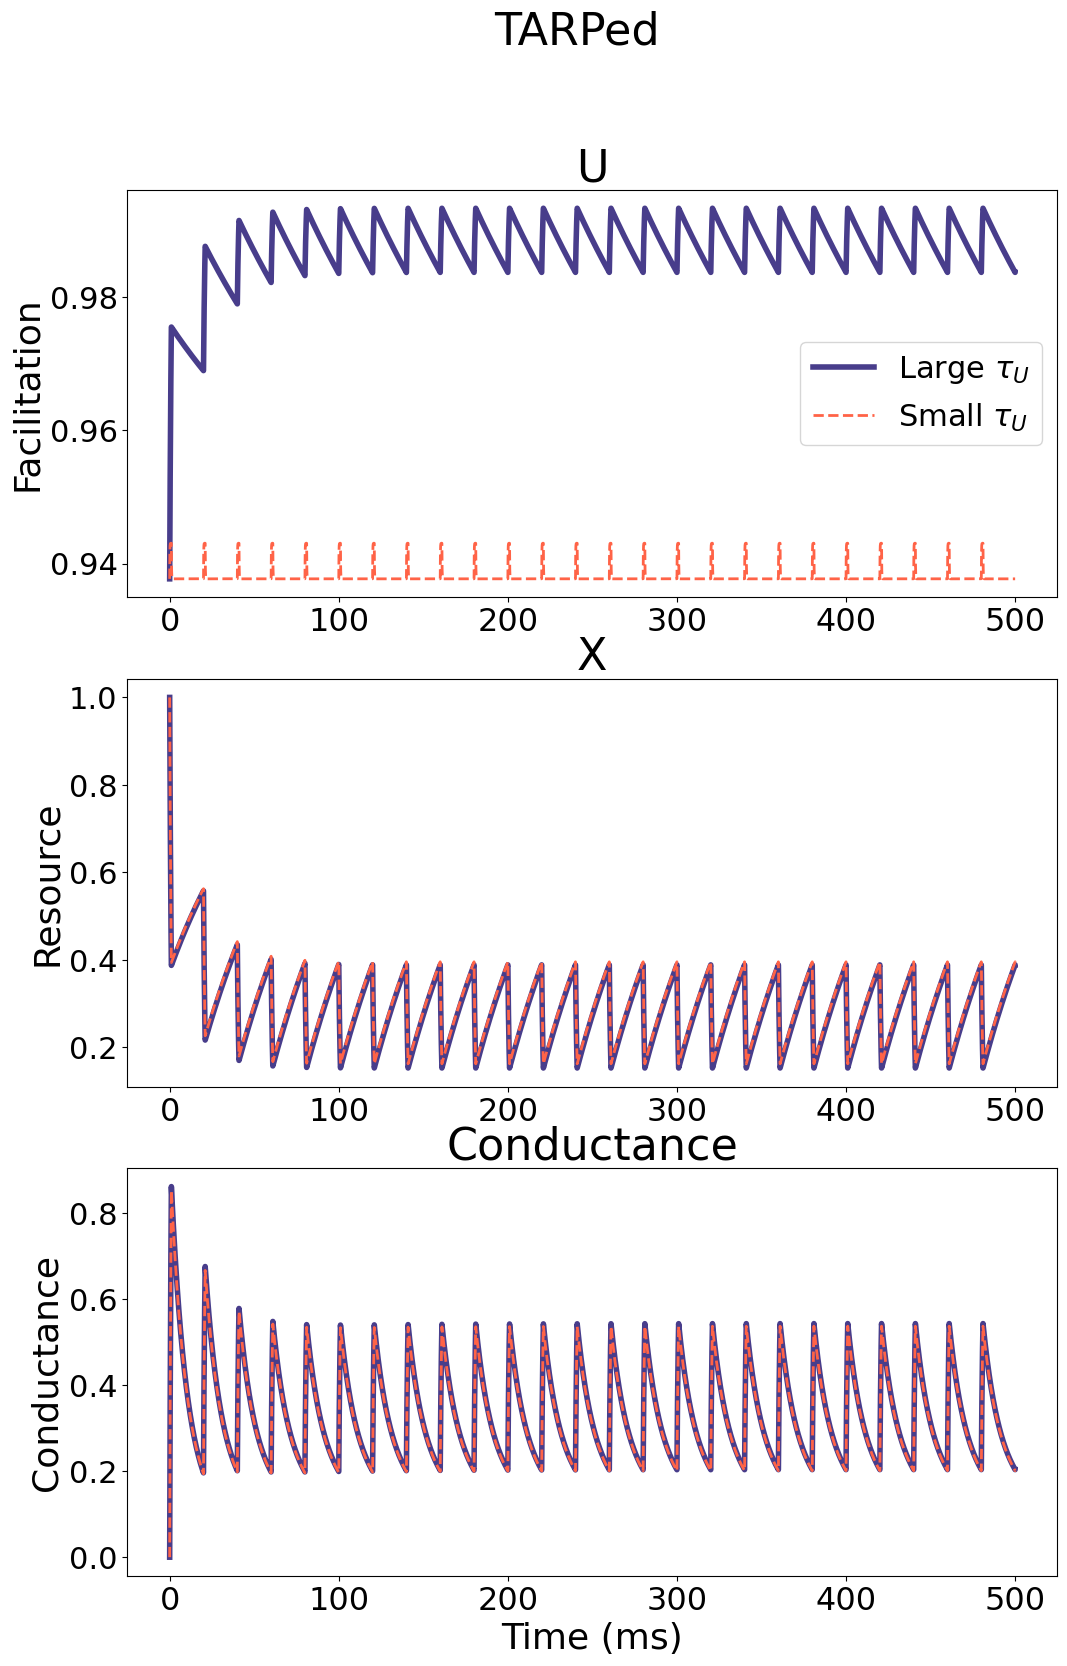

In [ ]:
plt.figure(figsize=(12,18))

plt.suptitle('TARPed')
plt.subplot(3,1,1)
plt.plot(sol_norm_s.t, sol_norm_s.y[1], linewidth=4, label = r'Large $\tau_U$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[1], label=r'Small $\tau_U$', linestyle='--', color='tomato')
plt.title('U')
plt.ylabel('Facilitation')


# plt.ylim(-0.001, 0.1)
# plt.xlim(-1, 100)
plt.legend()

plt.subplot(3,1,2)
plt.plot(sol_norm_s.t, sol_norm_s.y[0], linewidth=4, label = r'Large $\tau_U$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[0], label=r'Small $\tau_U$', linestyle='--', color='tomato')
plt.ylabel('Resource')
# plt.ylim(-0.001, 0.1)
# plt.xlim(-1, 100)
plt.title('X')

plt.subplot(3,1,3)
plt.plot(sol_norm_s.t, sol_norm_s.y[2] + sol_norm_s.y[3], linewidth=4, label = r'Large $\tau_U$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[2] + sol_norm_f.y[3], label=r'Small $\tau_U$', linestyle='--', color='tomato')
plt.title('Conductance')
plt.xlabel('Time (ms)')
plt.ylabel('Conductance')
# plt.ylim(-0.001, 0.05)
# plt.xlim(-1, 100)

# plt.savefig('Varying_tauU_TARPed_50Hz.pdf')

In [74]:
# Area under the curve of each
a = np.trapz(sol_norm_s.y[2] + sol_norm_s.y[3], sol_norm_s.t)
b = np.trapz(sol_norm_f.y[2] + sol_norm_f.y[3], sol_norm_f.t)

print('slow tauU = ', a)
print('fast tauU = ', b)

print('relative error = ', np.abs(a - b) / a, np.abs(b-a) / b)

slow tauU =  332.1235245136859
fast tauU =  328.3141322882623
relative error =  0.011469805491801691 0.011602888364485427


## Varying tauX

In [25]:
#TARPless
tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
taux, tauu, U_0 = [426.05575527,   0.66710861,   0.62727836]
y0 = np.array([1,U_0,0,0])



sol_norm_s = solve_ivp(time_2first_ord, [0, 1000], y0, args =  (3, 5, 1000, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
sol_norm_f = solve_ivp(time_2first_ord, [0, 1000], y0, args =  (3, 5, 1, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)

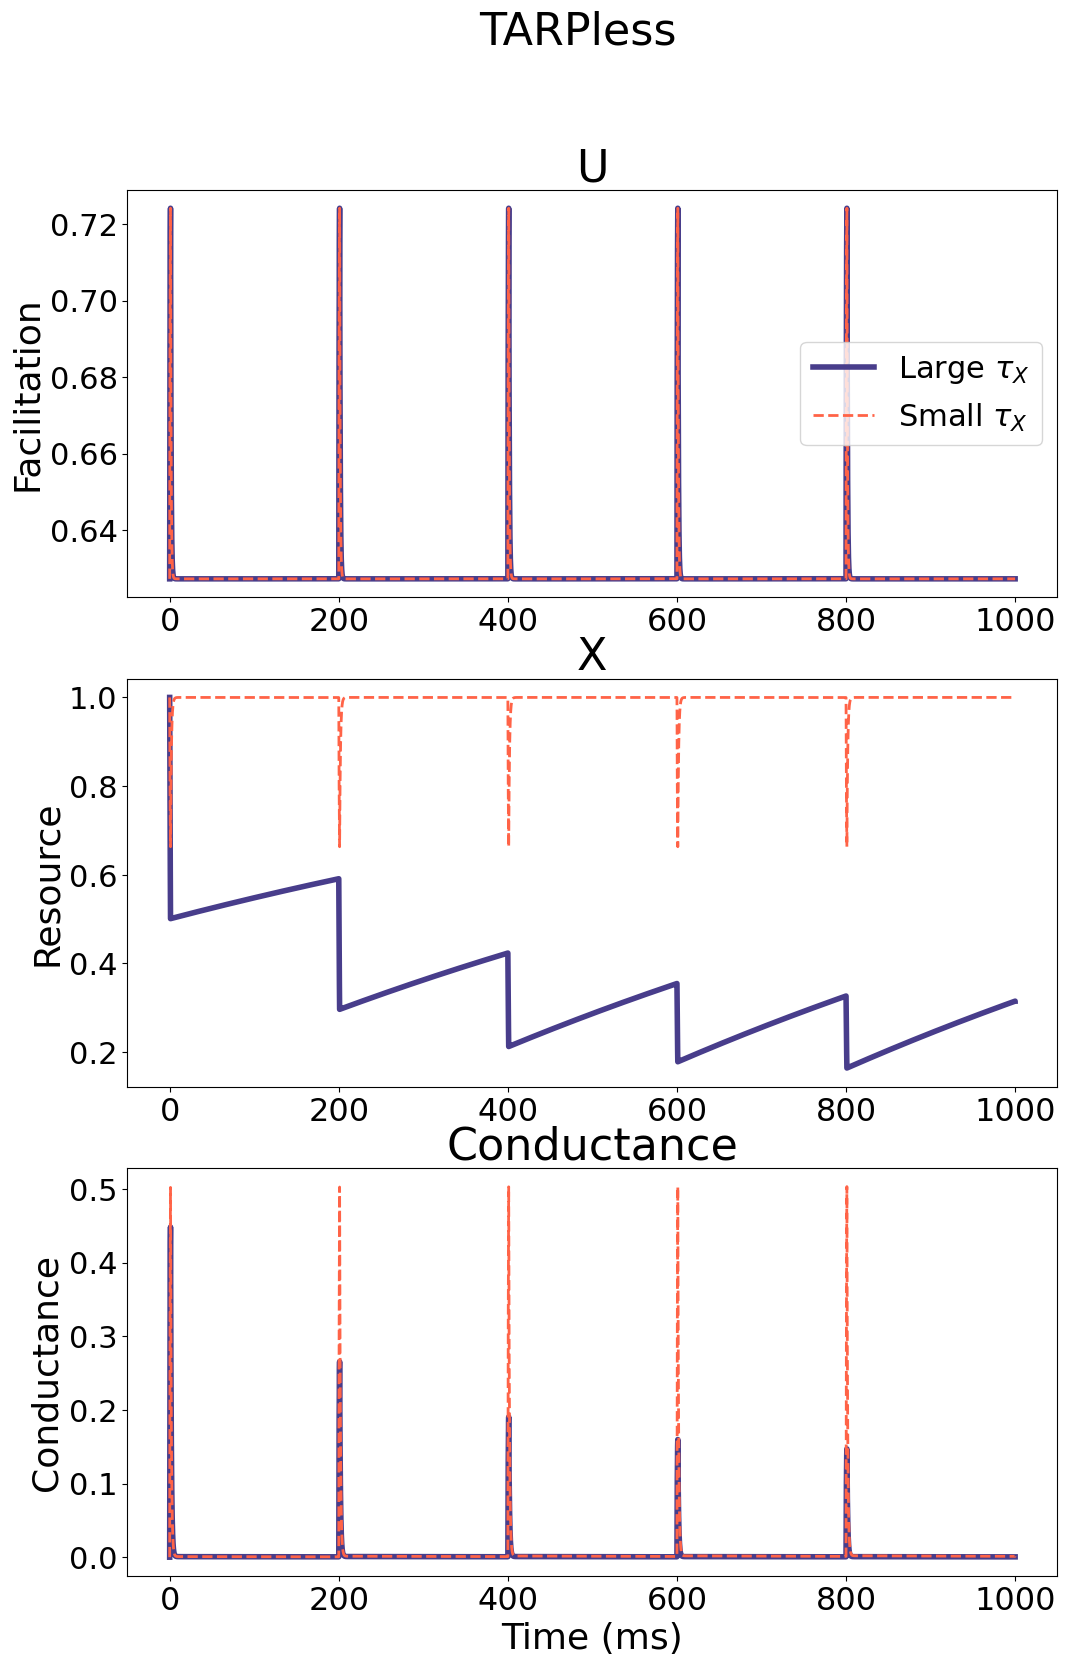

In [26]:
plt.figure(figsize=(12,18))

plt.suptitle('TARPless')
plt.subplot(3,1,1)
plt.plot(sol_norm_s.t, sol_norm_s.y[1], linewidth=4, label = r'Large $\tau_X$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[1], label=r'Small $\tau_X$', linestyle='--', color='tomato')
plt.title('U')
plt.ylabel('Facilitation')


# plt.ylim(-0.001, 0.1)
# plt.xlim(-1, 100)
plt.legend()

plt.subplot(3,1,2)
plt.plot(sol_norm_s.t, sol_norm_s.y[0], linewidth=4, label = r'Large $\tau_X$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[0], label=r'Small $\tau_X$', linestyle='--', color='tomato')
plt.ylabel('Resource')
# plt.ylim(-0.001, 0.1)
# plt.xlim(-1, 100)
plt.title('X')

plt.subplot(3,1,3)
plt.plot(sol_norm_s.t, sol_norm_s.y[2] + sol_norm_s.y[3], linewidth=4, label = r'Large $\tau_X$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[2] + sol_norm_f.y[3], label=r'Small $\tau_X$', linestyle='--', color='tomato')
plt.title('Conductance')
plt.xlabel('Time (ms)')
plt.ylabel('Conductance')
# plt.ylim(-0.001, 0.05)
# plt.xlim(-1, 100)

# plt.savefig('Varying_tauX_TARPless_5Hz.pdf')

In [81]:
# Area under the curve of each
a = np.trapz(sol_norm_s.y[2] + sol_norm_s.y[3], sol_norm_s.t)
b = np.trapz(sol_norm_f.y[2] + sol_norm_f.y[3], sol_norm_f.t)

print('slow tauX = ', a)
print('fast tauX = ', b)

print('relative error = ', np.abs(a - b) / a, np.abs(b-a) / b)

slow tauX =  3.629161632123364
fast tauX =  49.28283571816955
relative error =  12.579675063779112 0.9263605354838507


In [29]:
#TARPed
tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
y0 = np.array([1,U_0,0,0])
            #    taux=100, tauu=100, tauK=3, taug=5, A1=1, A2=1, alpha=1, U_0=0.5
sol_norm_s = solve_ivp(time_2first_ord, [0, 1000], y0, args =  (3, 5, 1000, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
sol_norm_f = solve_ivp(time_2first_ord, [0, 1000], y0, args =  (3, 5, 1, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


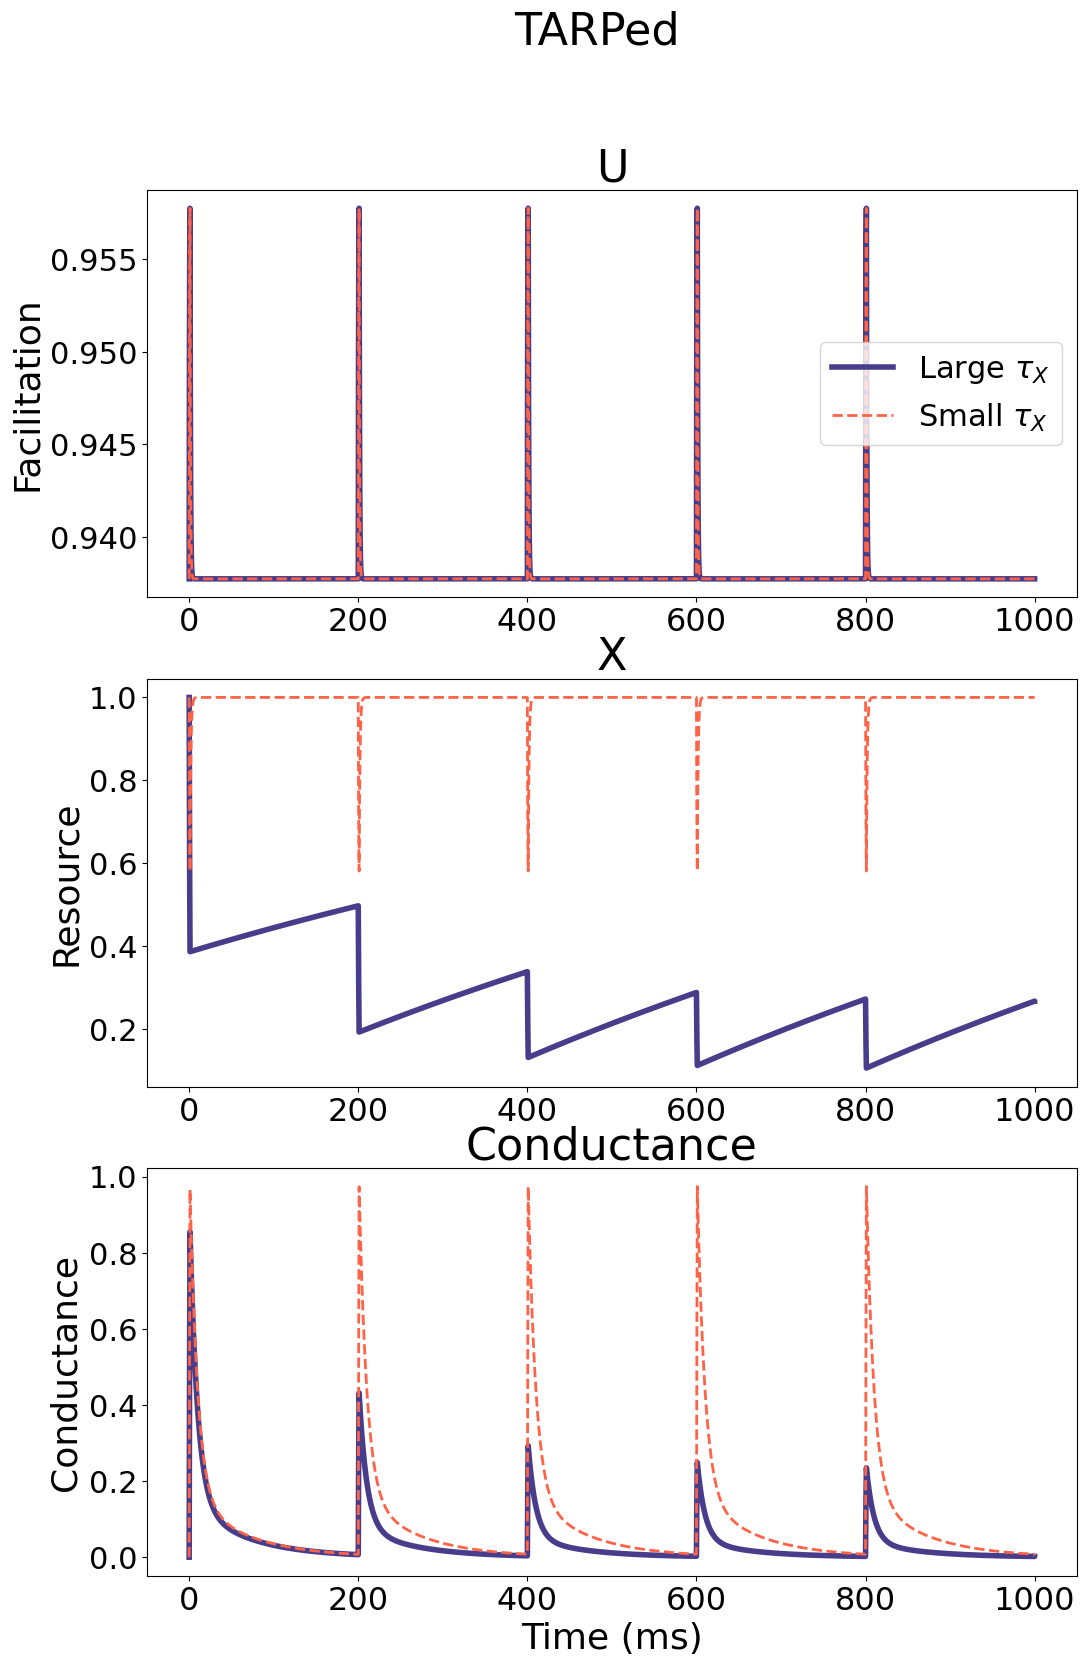

In [ ]:
plt.figure(figsize=(12,18))

plt.suptitle('TARPed')
plt.subplot(3,1,1)
plt.plot(sol_norm_s.t, sol_norm_s.y[1], linewidth=4, label = r'Large $\tau_X$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[1], label=r'Small $\tau_X$', linestyle='--', color='tomato')
plt.title('U')
plt.ylabel('Facilitation')


# plt.ylim(-0.001, 0.1)
# plt.xlim(-1, 100)
plt.legend()

plt.subplot(3,1,2)
plt.plot(sol_norm_s.t, sol_norm_s.y[0], linewidth=4, label = r'Large $\tau_X$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[0], label=r'Small $\tau_X$', linestyle='--', color='tomato')
plt.ylabel('Resource')
# plt.ylim(-0.001, 0.1)
# plt.xlim(-1, 100)
plt.title('X')

plt.subplot(3,1,3)
plt.plot(sol_norm_s.t, sol_norm_s.y[2] + sol_norm_s.y[3], linewidth=4, label = r'Large $\tau_X$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[2] + sol_norm_f.y[3], label=r'Small $\tau_X$', linestyle='--', color='tomato')
plt.title('Conductance')
plt.xlabel('Time (ms)')
plt.ylabel('Conductance')

# plt.ylim(-0.001, 0.05)
# plt.xlim(-1, 100)

# plt.savefig('Varying_tauX_TARPed_5Hz.pdf')

In [86]:
# Area under the curve of each
a = np.trapz(sol_norm_s.y[2] + sol_norm_s.y[3], sol_norm_s.t)
b = np.trapz(sol_norm_f.y[2] + sol_norm_f.y[3], sol_norm_f.t)

print('slow tauX = ', a)
print('fast tauX = ', b)

print('relative error = ', np.abs(a - b) / a, np.abs(b-a) / b)

slow tauX =  38.88112461959383
fast tauX =  91.15804356506413
relative error =  1.3445320694022769 0.5734756572321301


## Varying U_0

In [170]:
#TARPless
tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
taux, tauu, U_0 = [426.05575527,   0.66710861,   0.62727836]



            #    taux=100, tauu=100, tauK=3, taug=5, A1=1, A2=1, alpha=1, U_0=0.5
sol_norm_s = solve_ivp(time_2first_ord, [0, 1000], np.array([1,1,0,0]), args =  (3, 5, taux, taux, tauK, taug, A1, A2, alpha, 1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
sol_norm_f = solve_ivp(time_2first_ord, [0, 1000], np.array([1,0.1,0,0]), args =  (3, 5, taux, taux, tauK, taug, A1, A2, alpha, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)

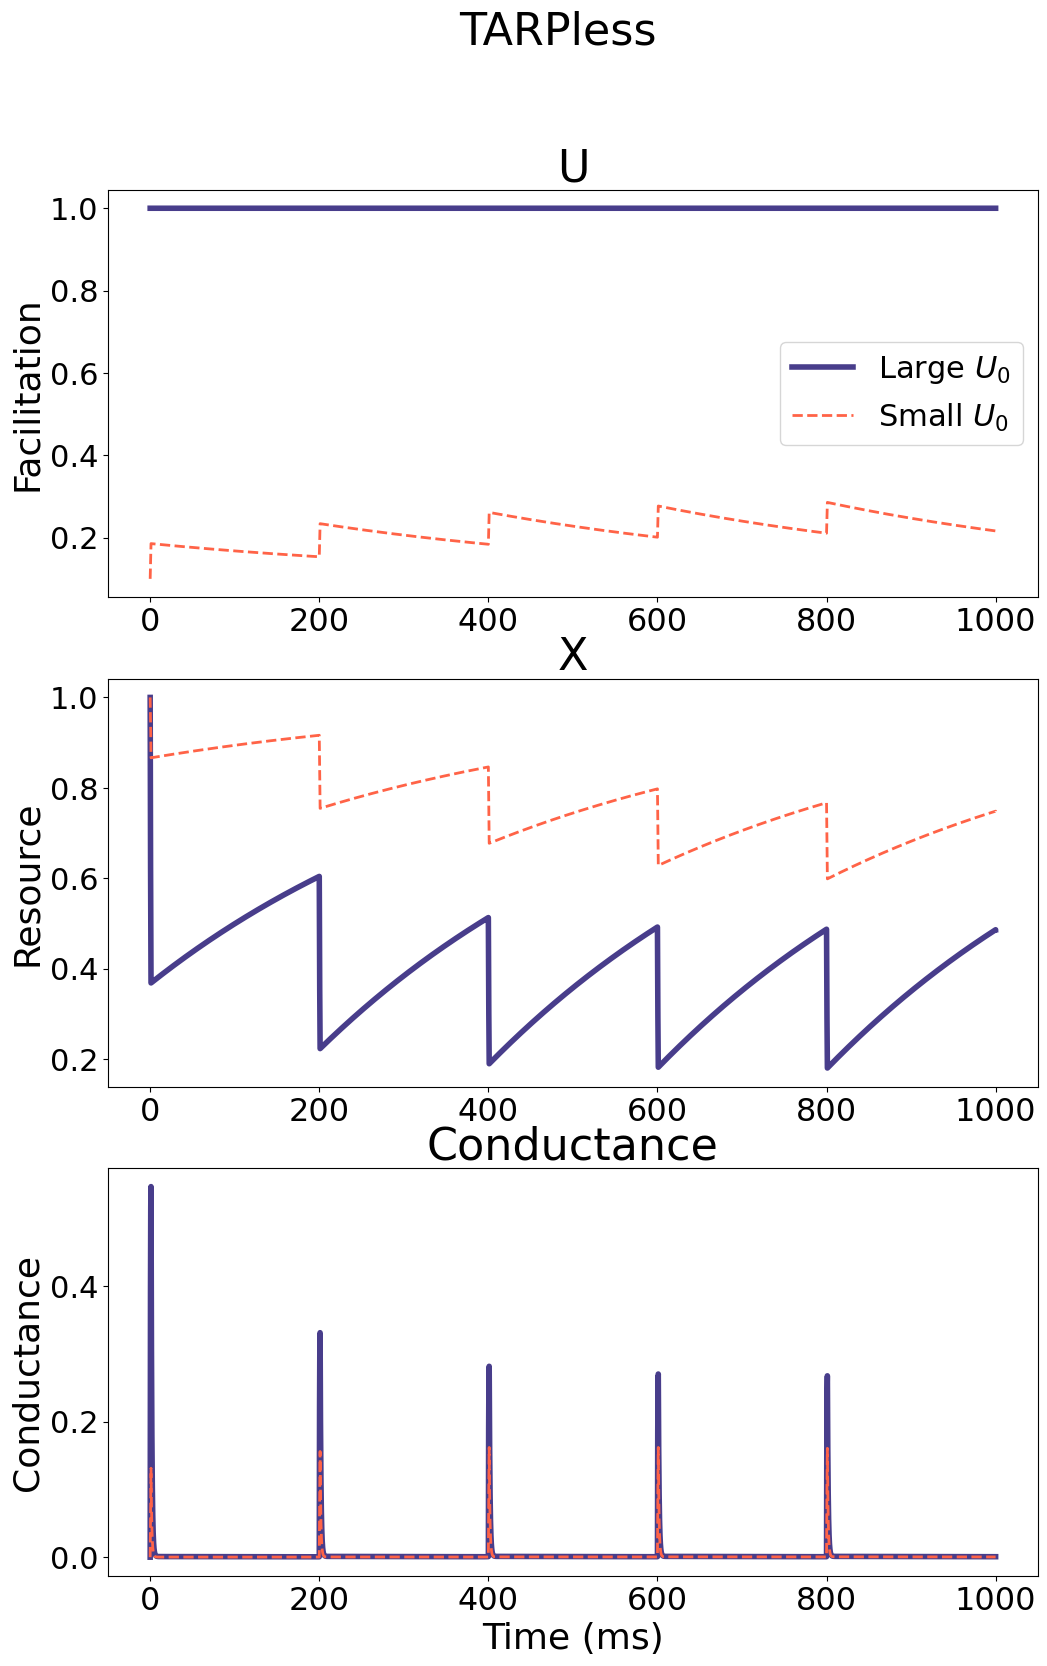

In [ ]:
plt.figure(figsize=(12,18))

plt.suptitle('TARPless')
plt.subplot(3,1,1)
plt.plot(sol_norm_s.t, sol_norm_s.y[1], linewidth=4, label = 'Large $U_0$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[1], label='Small $U_0$', linestyle='--', color='tomato')
plt.title('U')
plt.ylabel('Facilitation')


# plt.ylim(-0.001, 0.1)
# plt.xlim(-1, 100)
plt.legend()

plt.subplot(3,1,2)
plt.plot(sol_norm_s.t, sol_norm_s.y[0], linewidth=4, label = 'Large $U_0$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[0], label='Small $U_0$', linestyle='--', color='tomato')
plt.ylabel('Resource')
# plt.ylim(-0.001, 0.1)
# plt.xlim(-1, 100)
plt.title('X')

plt.subplot(3,1,3)
plt.plot(sol_norm_s.t, sol_norm_s.y[2] + sol_norm_s.y[3], linewidth=4, label = 'Large $U_0$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[2] + sol_norm_f.y[3], label='Small $U_0$', linestyle='--', color='tomato')
plt.title('Conductance')
plt.xlabel('Time (ms)')
plt.ylabel('Conductance')
# plt.ylim(-0.001, 0.05)
# plt.xlim(-1, 100)

# plt.savefig('Varying_U_0_TARPless_5Hz.pdf')

In [92]:
# Area under the curve of each
a = np.trapz(sol_norm_s.y[2] + sol_norm_s.y[3], sol_norm_s.t)
b = np.trapz(sol_norm_f.y[2] + sol_norm_f.y[3], sol_norm_f.t)

print('slow tauU = ', a)
print('fast tauU = ', b)

print('relative error = ', np.abs(a - b) / a, np.abs(b-a) / b)

slow tauU =  5.867751488586169
fast tauU =  5.527642032461795
relative error =  0.057962484741548415 0.06152884975673839


In [156]:
#TARPed
tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]


sol_norm_s = solve_ivp(time_2first_ord, [0, 500], np.array([1,1,0,0]), args =  (3, 50, taux, tauu, tauK, taug, A1, A2, alpha, 1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)

sol_norm_f = solve_ivp(time_2first_ord, [0, 500], np.array([1,0.1,0,0]), args =  (3, 50, taux, tauu, tauK, taug, A1, A2, alpha, 0.1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


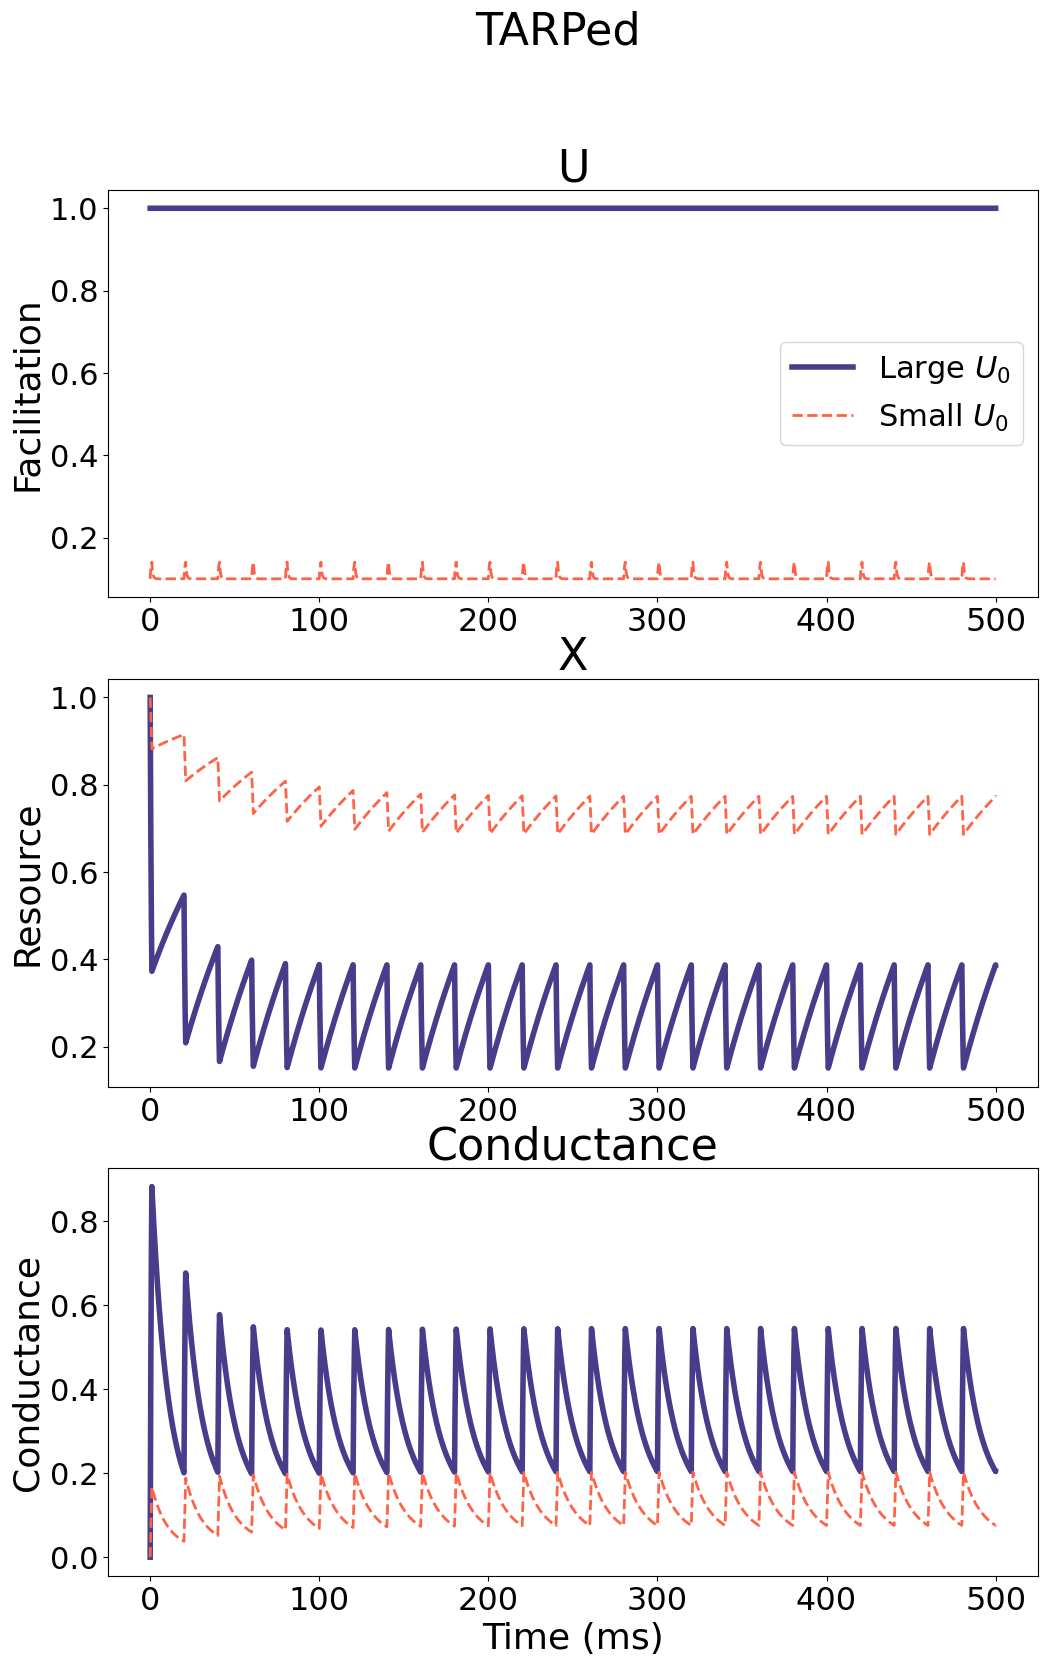

In [157]:
plt.figure(figsize=(12,18))

plt.suptitle('TARPed')
plt.subplot(3,1,1)
plt.plot(sol_norm_s.t, sol_norm_s.y[1], linewidth=4, label = 'Large $U_0$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[1], label='Small $U_0$', linestyle='--', color='tomato')
plt.title('U')
plt.ylabel('Facilitation')

plt.legend()

plt.subplot(3,1,2)
plt.plot(sol_norm_s.t, sol_norm_s.y[0], linewidth=4, label = 'Large $U_0$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[0], label='Small $U_0$', linestyle='--', color='tomato')
plt.ylabel('Resource')
# plt.ylim(-0.001, 0.1)
# plt.xlim(-1, 100)
plt.title('X')

plt.subplot(3,1,3)
plt.plot(sol_norm_s.t, sol_norm_s.y[2] + sol_norm_s.y[3], linewidth=4, label = 'Large $U_0$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[2] + sol_norm_f.y[3], label='Small $U_0$', linestyle='--', color='tomato')
plt.title('Conductance')
plt.xlabel('Time (ms)')
plt.ylabel('Conductance')
# plt.tight_layout()
# plt.ylim(-0.001, 0.05)
# plt.xlim(-1, 100)

plt.savefig('Varying_U_0_TARPed_50Hz.pdf')

In [153]:
# Area under the curve of each
a = np.trapz(sol_norm_s.y[2] + sol_norm_s.y[3], sol_norm_s.t)
b = np.trapz(sol_norm_f.y[2] + sol_norm_f.y[3], sol_norm_f.t)

print('slow tauU = ', a)
print('fast tauU = ', b)

print('relative error = ', np.abs(a - b) / a, np.abs(b-a) / b)

slow tauU =  78.32037899385054
fast tauU =  14.518955169895312
relative error =  0.8146209791574771 4.394353662324536


## Varying alpha

In [15]:
#TARPless
tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
taux, tauu, U_0 = [426.05575527,   0.66710861,   0.62727836]
y0 = np.array([1,U_0,0,0])



            #    taux=100, tauu=100, tauK=3, taug=5, A1=1, A2=1, alpha=1, U_0=0.5
sol_norm_s = solve_ivp(time_2first_ord, [0, 1000], y0, args =  (3, 5, taux, tauu, tauK, taug, A1, A2, 1, U_0), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
sol_norm_f = solve_ivp(time_2first_ord, [0, 1000], y0, args =  (3, 5, taux, tauu, tauK, taug, A1, A2, 0.1, U_0), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)

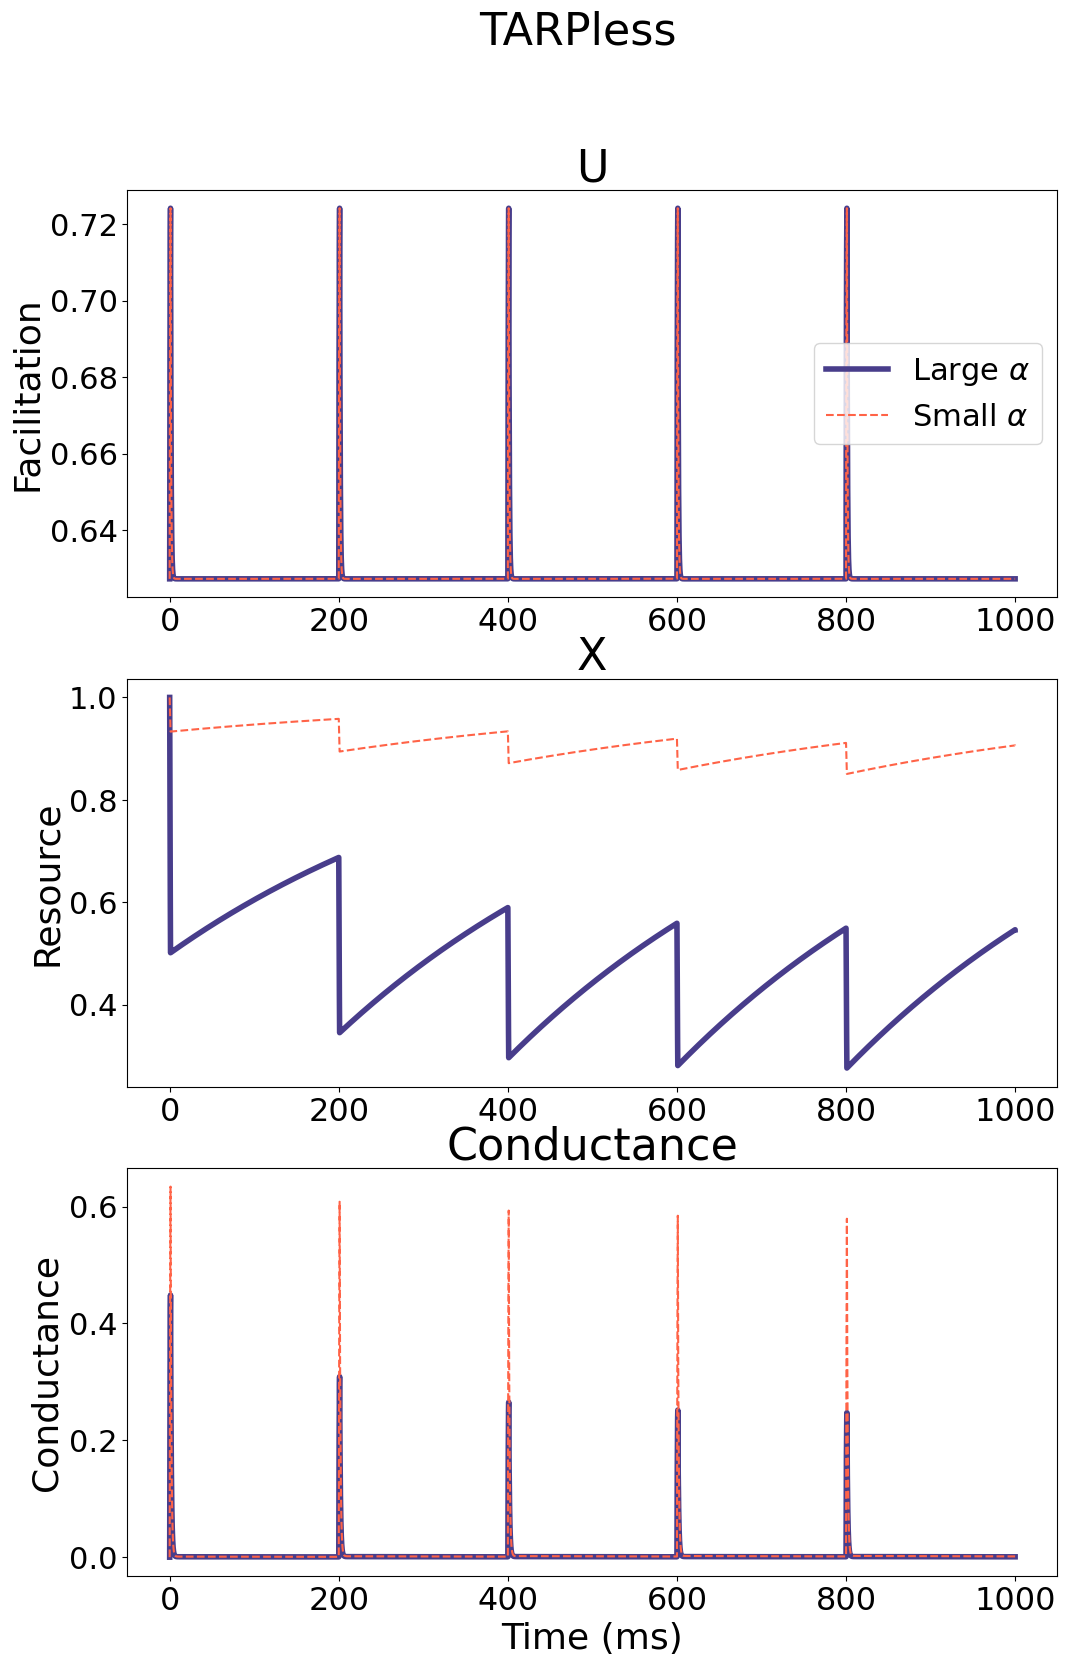

In [ ]:
plt.figure(figsize=(12,18))

plt.suptitle('TARPless')
plt.subplot(3,1,1)
plt.plot(sol_norm_s.t, sol_norm_s.y[1], linewidth=4, label = r'Large $\alpha$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[1], label=r'Small $\alpha$', linestyle='--', color='tomato', linewidth=1.5)
plt.title('U')
plt.ylabel('Facilitation')


# plt.ylim(-0.001, 0.1)
# plt.xlim(-1, 100)
plt.legend()

plt.subplot(3,1,2)
plt.plot(sol_norm_s.t, sol_norm_s.y[0], linewidth=4, label = r'Large $\alpha$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[0], label=r'Small $\alpha$', linestyle='--', color='tomato', linewidth=1.5)
plt.ylabel('Resource')
# plt.ylim(-0.001, 0.1)
# plt.xlim(-1, 100)
plt.title('X')

plt.subplot(3,1,3)
plt.plot(sol_norm_s.t, sol_norm_s.y[2] + sol_norm_s.y[3], linewidth=4, label = r'Large $\alpha$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[2] + sol_norm_f.y[3], label=r'Small $\alpha$', linestyle='--', color='tomato', linewidth=1.5)

plt.title('Conductance')
plt.xlabel('Time (ms)')
plt.ylabel('Conductance')
# plt.ylim(-0.001, 0.05)
# plt.xlim(-1, 100)

# plt.savefig('Varying_alpha_TARPless_5Hz.pdf')

In [95]:
# Area under the curve of each
a = np.trapz(sol_norm_s.y[2] + sol_norm_s.y[3], sol_norm_s.t)
b = np.trapz(sol_norm_f.y[2] + sol_norm_f.y[3], sol_norm_f.t)

print('slow tauU = ', a)
print('fast tauU = ', b)

print('relative error = ', np.abs(a - b) / a, np.abs(b-a) / b)

slow tauU =  5.699876270967037
fast tauU =  32.1707394899737
relative error =  4.644111900084391 0.8228242072973344


In [21]:
#TARPed
tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
y0 = np.array([1,U_0,0,0])

            #    taux=100, tauu=100, tauK=3, taug=5, A1=1, A2=1, alpha=1, U_0=0.5
sol_norm_s = solve_ivp(time_2first_ord, [0, 1000], y0, args =  (3, 5, taux, tauu, tauK, taug, A1, A2, 1, U_0), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
sol_norm_f = solve_ivp(time_2first_ord, [0, 1000], y0, args =  (3, 5, taux, tauu, tauK, taug, A1, A2, 0.1, U_0), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)


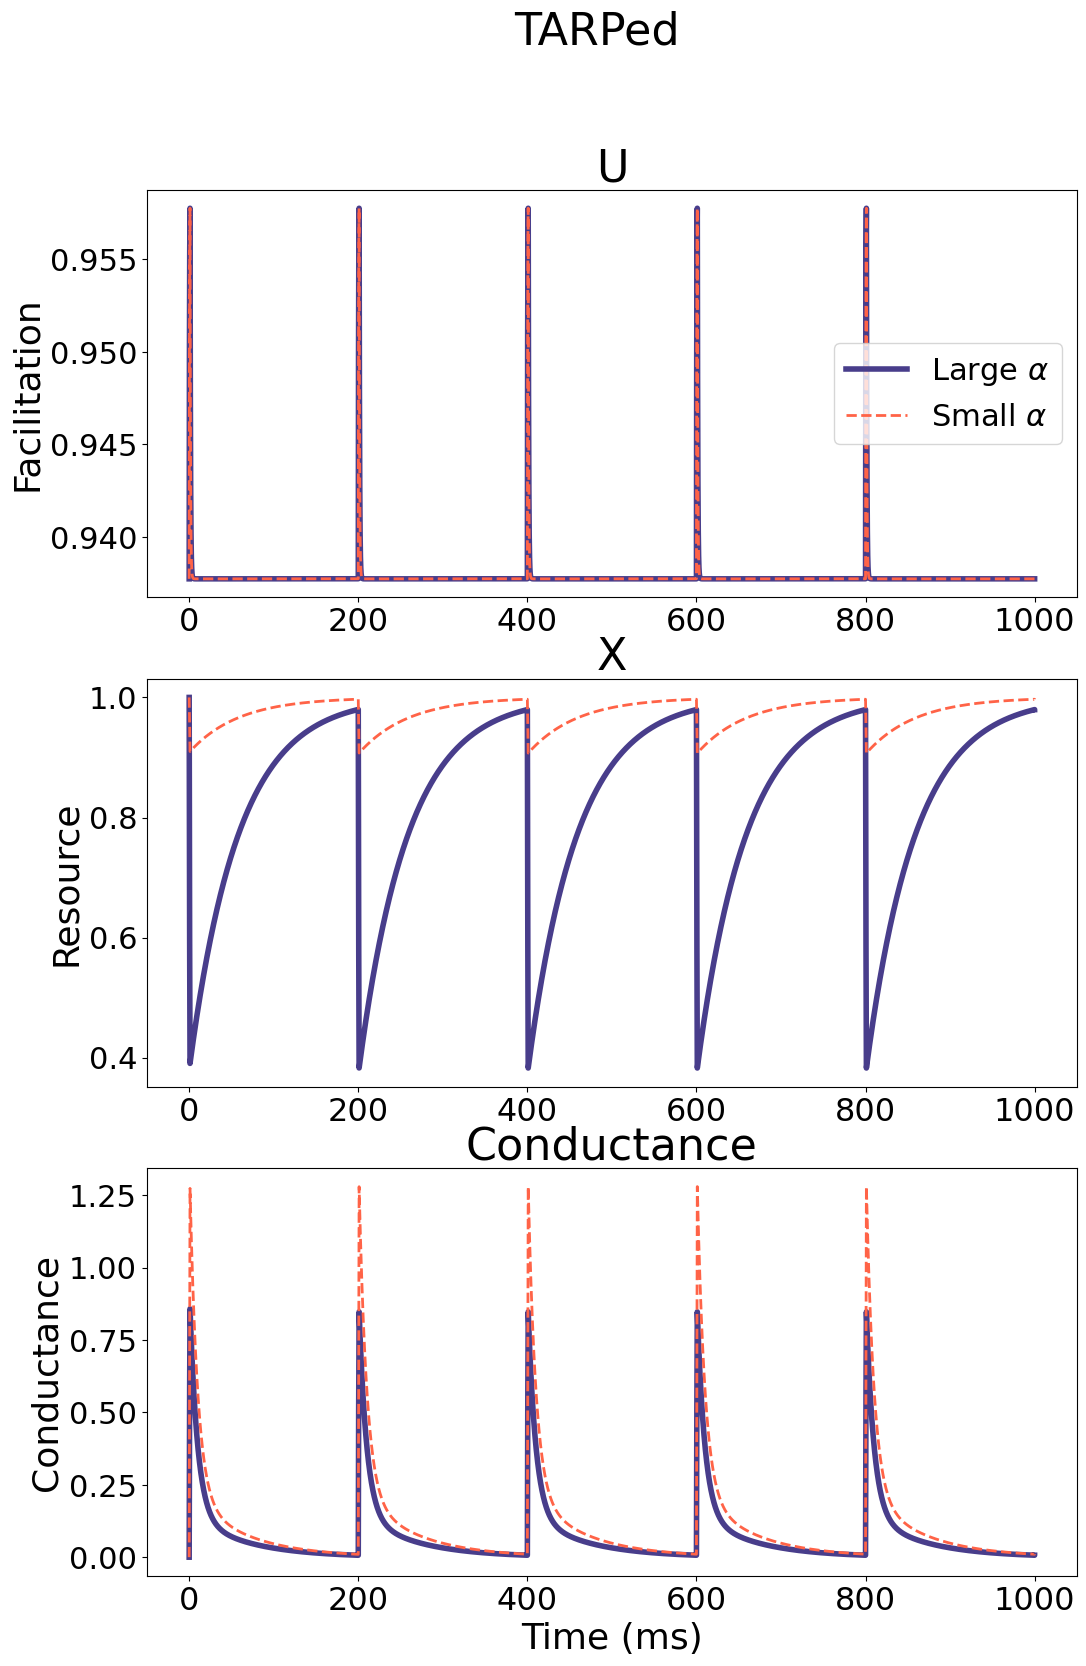

In [ ]:
plt.figure(figsize=(12,18))

plt.suptitle('TARPed')
plt.subplot(3,1,1)
plt.plot(sol_norm_s.t, sol_norm_s.y[1], linewidth=4, label = r'Large $\alpha$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[1], label=r'Small $\alpha$', linestyle='--', color='tomato')
plt.title('U')
plt.ylabel('Facilitation')


# plt.ylim(-0.001, 0.1)
# plt.xlim(-1, 100)
plt.legend()

plt.subplot(3,1,2)
plt.plot(sol_norm_s.t, sol_norm_s.y[0], linewidth=4, label = r'Large $\alpha$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[0], label=r'Small $\alpha$', linestyle='--', color='tomato')
plt.ylabel('Resource')
# plt.ylim(-0.001, 0.1)
# plt.xlim(-1, 100)
plt.title('X')

plt.subplot(3,1,3)
plt.plot(sol_norm_s.t, sol_norm_s.y[2] + sol_norm_s.y[3], linewidth=4, label = r'Large $\alpha$', color='darkslateblue')
plt.plot(sol_norm_f.t, sol_norm_f.y[2] + sol_norm_f.y[3], label=r'Small $\alpha$', linestyle='--', color='tomato')
plt.title('Conductance')
plt.xlabel('Time (ms)')
plt.ylabel('Conductance')
# plt.ylim(-0.001, 0.05)
# plt.xlim(-1, 100)

# plt.savefig('Varying_alpha_TARPed_5Hz.pdf')

In [106]:
# Area under the curve of each
a = np.trapz(sol_norm_s.y[2] + sol_norm_s.y[3], sol_norm_s.t)
b = np.trapz(sol_norm_f.y[2] + sol_norm_f.y[3], sol_norm_f.t)

print('slow tauU = ', a)
print('fast tauU = ', b)

print('relative error = ', np.abs(a - b) / a, np.abs(b-a) / b)

slow tauU =  79.83846802546431
fast tauU =  119.4107011599534
relative error =  0.49565371321839014 0.3313960369555252


## Testing function without any U

In [9]:
def time_2first_ord_noU(t, x, glut_type=0, t2=10000, taux=100, tauu=100, tauK=3, taug=5, A1=1, A2=1, alpha=1, U_0=0.5):
    
    X = x[0]
    U = x[1]
    K = x[2]
    g = x[3]
    
    
#   exponential pulses
    if glut_type == 0:
        if  t<t2:
            glutamate = 1*(np.exp(-(t)/tauS))
        else:
            glutamate = 1*((np.exp(-(t)/tauS) + np.exp(-(t-t2)/tauS)))
        # 1/100 to make it in terms of 10mM instead of M
        
#   Square pulses
    if glut_type == 1:
        if t>0 and t<=1:   
            glutamate = 1
        else:
            glutamate = 0

#   Step increase 
    if glut_type == 2:
        if t>10 :   
            glutamate = 1
        else:
            glutamate = 0

#   Periodic square pulses
    if glut_type == 3:
        if t%(1000/t2)<=1:
            glutamate = 1
        else:
            glutamate = 0
            
#   Sinusodial signal
    if glut_type == 4:
        glutamate = 0.005*(1+np.sin(2*np.pi*(t2/1000)*t))
        
#   Paired Square Pulse
    if glut_type == 5:
        if t>=0 and t<100 or t>=t2 and t<100+t2:   
            glutamate = 1
        else:
            glutamate = 0

            
#   Square pulse of certain length
    if glut_type == 6:
        if t>=0 and t<t2:  
            glutamate = 1
        else:
            glutamate = 0
        

    
    dU = 0
    
    dX = (1-X)/taux - (alpha * U_0 * X)*glutamate#(alpha * U_plus * X)*glutamate

        
    dK = -K/tauK + (A1 * U_0 * X)*glutamate #(A1 * U_plus * X)*glutamate
    dg = -g/taug + (A2 * U_0 * X)*glutamate #(A2 * U_plus * X)*glutamate


    return np.array([dX, dU, dK, dg])

In [11]:
alpha = 6   # Deactivation rate
beta = 10    # Activation rate
k_plus1 = 1e4 # Binding rate of molecule to AMPAR (R to RG)
k_minus1 = 50  # Unbinding rate of molecule from AMPAR (RG to R)
CC = 36.5      # Transition from RG to RG* (channel activating)
CO = 4.55     # Transition from RG* to RG (Channel deactivating)
CS_plus1 = 0.3   # Transition from RG* to RG*2
CS_minus1 = 10.0 # Transition from desensitized state RG*2 to RG*
gamma1  = .003 # Recovery rate
gamma2 = .03
delta1 = 1.1    # Desensitization rate from D1 to RG*
delta2 = .3    # Desensitization rate from D2 to RG*2
tauS = 3

solRH = solve_ivp(Milstein2007, [0, 1000], y3, args =  (3, 36.5, 4.55, 0.3, 10.0, .003, 0.03, 10.0, 5, 1.1, 0.3, 1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)
solRHT = solve_ivp(Milstein2007, [0, 1000], y3, args = (3, 25, 2.5, 1.0, 3.4, .03, 0.03, 100.0, 5, 1.1, 0.3, 1), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.1)

In [12]:
#TARPless
tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
taux, tauu, U_0 = [426.05575527,   0.66710861,   0.62727836]
y0 = np.array([1,U_0,0,0])

sol_norm_s = solve_ivp(time_2first_ord_noU, [0, 1000], y0, args =  (3, 5, taux, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.11)
sol_norm_f = solve_ivp(time_2first_ord, [0, 1000], y0, args =  (3, 5, taux, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRH.t, rtol=1e-8, method='LSODA', max_step=0.11)


# TARPed
tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
y0 = np.array([1,U_0,0,0])
sol_TARP_s = solve_ivp(time_2first_ord_noU, [0, 1000], y0, args =  (3, 5, taux, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRHT.t, rtol=1e-8, method='LSODA', max_step=0.11)
sol_TARP_f = solve_ivp(time_2first_ord, [0, 1000], y0, args =  (3, 5, taux, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, t_eval=solRHT.t, rtol=1e-8, method='LSODA', max_step=0.11)

C:\Users\brian\AppData\Local\Temp\ipykernel_13176\2461879492.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


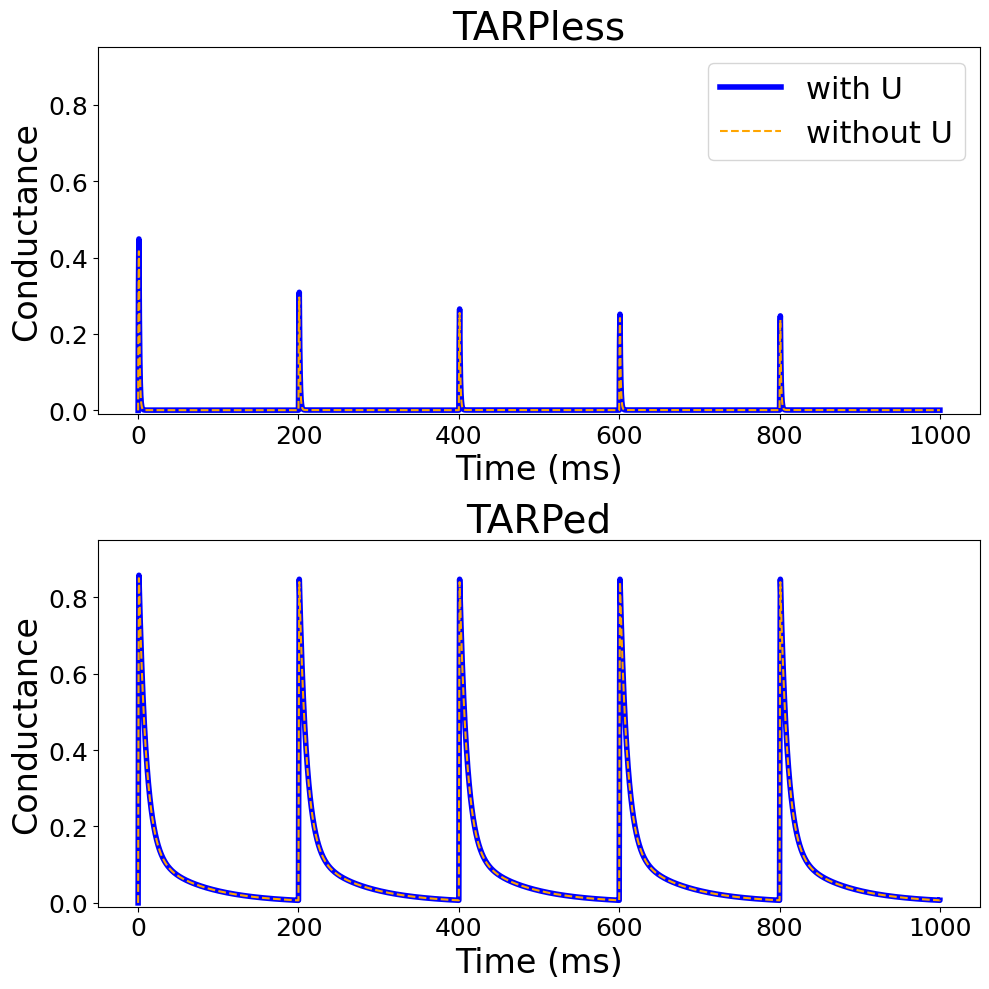

In [13]:
plt.figure(figsize=(10,10))

plt.subplot(2,1,1)
plt.plot(sol_norm_f.t, sol_norm_f.y[2] + sol_norm_f.y[3], label='with U', color='blue', linewidth=4)
plt.plot(sol_norm_s.t, sol_norm_s.y[2] + sol_norm_s.y[3], linewidth=1.5, label = 'without U', linestyle='--', color='orange')
# plt.plot(solRH.t, solRH.y[2] + 2*solRH.y[5], label='KR model', linestyle=':', color='green', linewidth=2)

plt.title('TARPless', fontsize=28)
plt.xlabel('Time (ms)', fontsize=24)
plt.ylabel('Conductance', fontsize=24)
plt.legend(fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.yscale('log')
plt.ylim(-.01, 0.95)
# plt.ylim(0.0005, 0.95)
plt.tight_layout()
plt.legend()

plt.subplot(2,1,2)

plt.plot(sol_TARP_f.t, sol_TARP_f.y[2] + sol_TARP_f.y[3], label='with U', color='blue', linewidth=4)
plt.plot(sol_TARP_s.t, sol_TARP_s.y[2] + sol_TARP_s.y[3], linewidth=1.5, label = 'without U', linestyle='--', color='orange')
# plt.plot(solRHT.t, solRHT.y[2] + 2*solRHT.y[5], label='KR model', linestyle=':', color='green', linewidth=1.5)
plt.title('TARPed', fontsize=28)
plt.xlabel('Time (ms)', fontsize=24)
plt.ylabel('Conductance', fontsize=24)
# plt.legend(fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.yscale('log')
plt.ylim(-.01, 0.95)
# plt.ylim(0.0005, 0.95)
plt.tight_layout()

# plt.savefig('noU_effect_50Hz.pdf', dpi=600)


In [96]:
# Area under the curve of each
noU_area_TARPless = np.trapz(sol_norm_s.y[2] + sol_norm_s.y[3], sol_norm_s.t)
normal_area_TARPless = np.trapz(sol_norm_f.y[2] + sol_norm_f.y[3], sol_norm_f.t)
Milstein_area_TARPless = np.trapz(solRH.y[2] + 2*solRH.y[5], solRH.t)
print(noU_area_TARPless)
print(normal_area_TARPless)
print(Milstein_area_TARPless)
print('with U relative error = ', np.abs((Milstein_area_TARPless - normal_area_TARPless) / Milstein_area_TARPless))
print('no U relative error = ', np.abs((Milstein_area_TARPless - noU_area_TARPless) / Milstein_area_TARPless))
print('no U relative error = ', np.abs((normal_area_TARPless - noU_area_TARPless) / normal_area_TARPless))

3.0483807566634047
3.1930971340963517
3.4559002243262027
with U relative error =  0.0760447562634971
no U relative error =  0.11791991701445956
no U relative error =  0.04532163330944262


In [97]:
# Area under the curve of each
noU_area_TARPed = np.trapz(sol_TARP_s.y[2] + sol_TARP_s.y[3], sol_TARP_s.t)
normal_area_TARPed = np.trapz(sol_TARP_f.y[2] + sol_TARP_f.y[3], sol_TARP_f.t)
Milstein_area_TARPed = np.trapz(solRHT.y[2] + 2*solRHT.y[5], solRHT.t)
print(noU_area_TARPed)
print(normal_area_TARPed)
print(Milstein_area_TARPed)
print('with U relative error = ', np.abs((Milstein_area_TARPed - normal_area_TARPed) / Milstein_area_TARPed))
print('no U relative error = ', np.abs((Milstein_area_TARPed - noU_area_TARPed) / Milstein_area_TARPed))
print('no U relative error = ', np.abs((normal_area_TARPed - noU_area_TARPed) / normal_area_TARPed))

79.13700790595006
79.84067707318508
84.17863158911962
with U relative error =  0.05153272789118654
no U relative error =  0.059891965312265885
no U relative error =  0.008813416832500176


In [98]:
print('Milstein vs with U ', np.sum((np.log((sol_norm_f.y[2,1:] + sol_norm_f.y[3,1:]))-np.log(solRH.y[2,1:] + 2*solRH.y[5,1:]))**2))
print('Milstein vs no U ', np.sum((np.log((sol_norm_s.y[2,1:] + sol_norm_s.y[3,1:]))-np.log(solRH.y[2,1:] + 2*solRH.y[5,1:]))**2))
print('with U vs no U ', np.sum((np.log((sol_norm_f.y[2,1:] + sol_norm_f.y[3,1:]))-np.log(sol_norm_s.y[2,1:] + sol_norm_s.y[3,1:]))**2))

print('Milstein vs with U ', np.sum((((sol_norm_f.y[2,1:] + sol_norm_f.y[3,1:]))-(solRH.y[2,1:] + 2*solRH.y[5,1:]))**2))
print('Milstein vs no U ', np.sum((((sol_norm_s.y[2,1:] + sol_norm_s.y[3,1:]))-(solRH.y[2,1:] + 2*solRH.y[5,1:]))**2))
print('with U vs no U ', np.sum((((sol_norm_f.y[2,1:] + sol_norm_f.y[3,1:]))-(sol_norm_s.y[2,1:] + sol_norm_s.y[3,1:]))**2))


Milstein vs with U  1304.1771156086636
Milstein vs no U  1355.89734925431
with U vs no U  28.221349286799565
Milstein vs with U  10.486933323005733
Milstein vs no U  10.907360369025513
with U vs no U  0.16567824751040294


In [99]:
diff_f = np.log(sol_TARP_f.y[2,1:] + sol_TARP_f.y[3,1:]) \
         - np.log(solRHT.y[2,1:] + 2*solRHT.y[5,1:])

diff_s = np.log(sol_TARP_s.y[2,1:] + sol_TARP_s.y[3,1:]) \
         - np.log(solRHT.y[2,1:] + 2*solRHT.y[5,1:])

diff_fs = np.log(sol_TARP_f.y[2,1:] + sol_TARP_f.y[3,1:]) \
          - np.log(sol_TARP_s.y[2,1:] + sol_TARP_s.y[3,1:])

print("RMS log difference:")
print("Milstein vs with U:", np.sqrt(np.mean(diff_f**2)))
print("Milstein vs no U:",  np.sqrt(np.mean(diff_s**2)))
print("with U vs no U:",     np.sqrt(np.mean(diff_fs**2)))


RMS log difference:
Milstein vs with U: 0.35090112128679096
Milstein vs no U: 0.35244505350805994
with U vs no U: 0.008704570363293062


## Testing function without any X

You can find a constant to insert instead of X for each frequency, but unlike for U, each frequency needs a new constant value for X. I find this out [here](Tsodyks_model_X_replacement.ipynb)

In [119]:
def time_2first_ord_noX(t, x, glut_type=0, t2=10000, taux=100, tauu=100, tauK=3, taug=5, A1=1, A2=1, alpha=1, U_0=0.5):
    
    X = x[0]
    U = x[1]
    K = x[2]
    g = x[3]
    
    
#   exponential pulses
    if glut_type == 0:
        if  t<t2:
            glutamate = 1*(np.exp(-(t)/tauS))
        else:
            glutamate = 1*((np.exp(-(t)/tauS) + np.exp(-(t-t2)/tauS)))
        # 1/100 to make it in terms of 10mM instead of M
        
#   Square pulses
    if glut_type == 1:
        if t>0 and t<=1:   
            glutamate = 1
        else:
            glutamate = 0

#   Step increase 
    if glut_type == 2:
        if t>10 :   
            glutamate = 1
        else:
            glutamate = 0

#   Periodic square pulses
    if glut_type == 3:
        if t%(1000/t2)<=1:
            glutamate = 1
        else:
            glutamate = 0
            
#   Sinusodial signal
    if glut_type == 4:
        glutamate = 0.005*(1+np.sin(2*np.pi*(t2/1000)*t))
        
#   Paired Square Pulse
    if glut_type == 5:
        if t>=0 and t<100 or t>=t2 and t<100+t2:   
            glutamate = 1
        else:
            glutamate = 0

            
#   Square pulse of certain length
    if glut_type == 6:
        if t>=0 and t<t2:  
            glutamate = 1
        else:
            glutamate = 0
        

    
    U_plus = U #+ (U_0 * (1.0 - U))*glutamate
    dU = (U_0 - U)/tauu + (U_0 * (1.0 - U))*glutamate
    
    dX = 0

        
    dK = -K/tauK + (A1 * U_plus * 0.2)*glutamate #(A1 * U_plus * X)*glutamate
    dg = -g/taug + (A2 * U_plus * 0.2)*glutamate #(A2 * U_plus * X)*glutamate


    return np.array([dX, dU, dK, dg])

In [121]:
#TARPless
tauK, taug, A1, A2, alpha = [9.28782606e-01, 4.02802597e+02, 1.53943493e+00, 1.51940434e-03, 1]
taux, tauu, U_0 = [426.05575527,   0.66710861,   0.62727836]
y0 = np.array([1,U_0,0,0])

sol_norm_s = solve_ivp(time_2first_ord_noX, [0, 2000], y0, args =  (3, 5, taux, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.11)
sol_norm_f = solve_ivp(time_2first_ord, [0, 2000], y0, args =  (3, 5, taux, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.11)


# TARPed
tauK, taug, A1, A2, alpha = [9.02833091, 64.51534201,  1.23175149,  0.23848164, 1]
taux, tauu, U_0 = [58.24952329715077,   0.560184338771549, 0.9377337949271534]
y0 = np.array([1,U_0,0,0])

sol_TARP_s = solve_ivp(time_2first_ord_noX, [0, 2000], y0, args =  (3, 5, taux, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.11)
sol_TARP_f = solve_ivp(time_2first_ord, [0, 2000], y0, args =  (3, 5, taux, tauu, tauK, taug, A1, A2, alpha, U_0), dense_output=True, rtol=1e-8, method='LSODA', max_step=0.11)

C:\Users\brian\AppData\Local\Temp\ipykernel_25128\2235157884.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


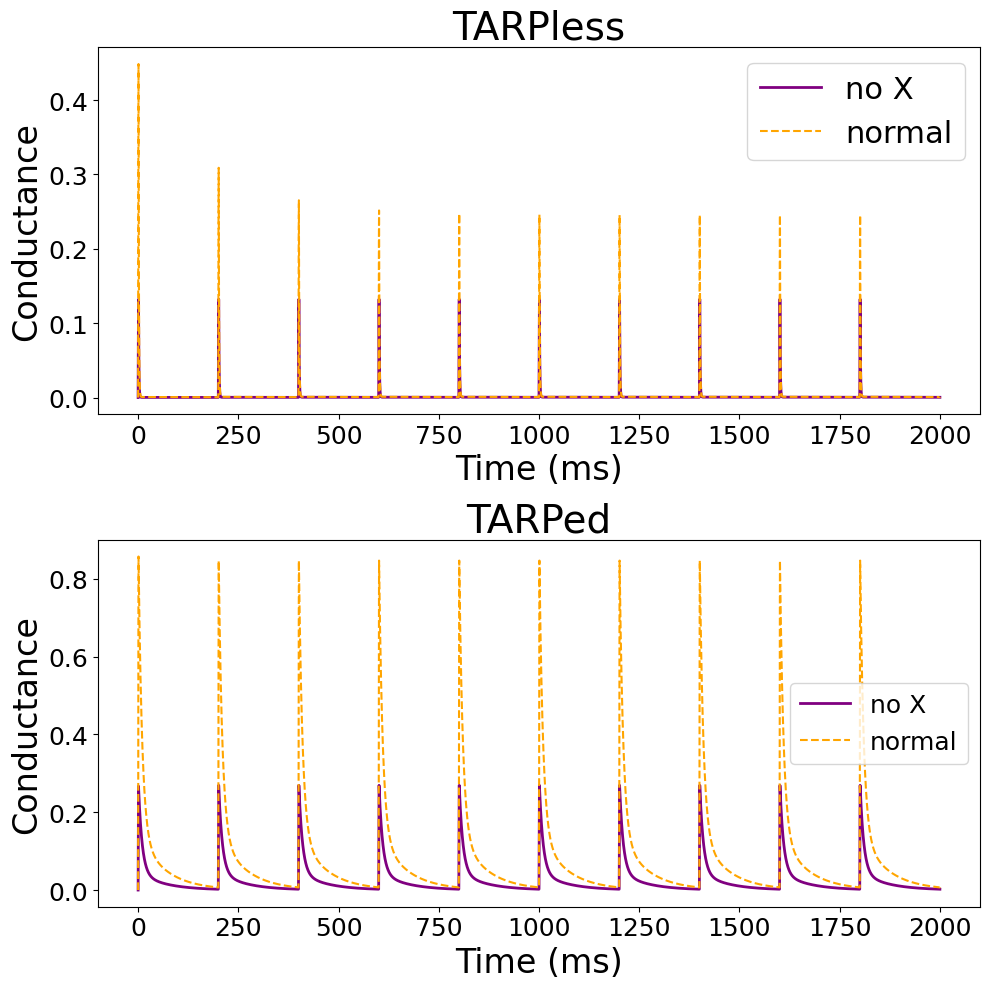

In [ ]:
plt.figure(figsize=(10,10))

plt.subplot(2,1,1)
plt.plot(sol_norm_s.t, sol_norm_s.y[2] + sol_norm_s.y[3], linewidth=2, label = 'no X', color='purple')
plt.plot(sol_norm_f.t, sol_norm_f.y[2] + sol_norm_f.y[3], label='normal', linestyle='--', color='orange', linewidth=1.5)
# plt.xlim(-1, 130)
# plt.ylim(-0.001, 0.02)
plt.title('TARPless', fontsize=28)
plt.xlabel('Time (ms)', fontsize=24)
plt.ylabel('Conductance', fontsize=24)
plt.legend(fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.yscale('log')
# plt.ylim(0.0001, 0.9)
plt.tight_layout()
plt.legend()

plt.subplot(2,1,2)

plt.plot(sol_TARP_s.t, sol_TARP_s.y[2] + sol_TARP_s.y[3], linewidth=2, label = 'no X', color='purple')
plt.plot(sol_TARP_f.t, sol_TARP_f.y[2] + sol_TARP_f.y[3], label='normal', linestyle='--', color='orange', linewidth=1.5)
plt.title('TARPed', fontsize=28)
plt.xlabel('Time (ms)', fontsize=24)
plt.ylabel('Conductance', fontsize=24)
plt.legend(fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.yscale('log')
# plt.ylim(0.0001, 0.9)
plt.tight_layout()

# plt.savefig('noX_effect_50Hz_log.pdf', dpi=600)
# plt.ylim(-0.001, 0.02)
# plt.xlim(-1, 150)

In [109]:
# Area under the curve of each
noU_area_TARPless = np.trapz(sol_norm_s.y[2] + sol_norm_s.y[3], sol_norm_s.t)
normal_area_TARPless = np.trapz(sol_norm_f.y[2] + sol_norm_f.y[3], sol_norm_f.t)
print(noU_area_TARPless)
print(normal_area_TARPless)
print('relative error = ', np.abs((normal_area_TARPless - noU_area_TARPless) / normal_area_TARPless))

2.5883321805758994
5.810362110673945
relative error =  0.554531691609892


In [110]:
# Area under the curve of each
noU_area_TARPed = np.trapz(sol_TARP_s.y[2] + sol_TARP_s.y[3], sol_TARP_s.t)
normal_area_TARPed = np.trapz(sol_TARP_f.y[2] + sol_TARP_f.y[3], sol_TARP_f.t)
print(noU_area_TARPed)
print(normal_area_TARPed)
print('relative error = ', np.abs((normal_area_TARPed - noU_area_TARPed) / normal_area_TARPed))

48.61359715668787
155.9557364515951
relative error =  0.6882859312342361
